#### 核心公式：ICIR (信息比率的变体)
##### IC 反映的是平均预测能力，而 ICIR 反映的是预测能力的稳定性。$$ICIR = \frac{Mean(Rank\_IC)}{Std(Rank\_IC)}$$

##### 如果 ICIR > 0.5，说明你的模型非常稳；如果 ICIR 只有 0.1，说明你的 0.0801 可能是靠某几天的爆发拉起来的，实盘风险很大。

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- 1. 重新定义 Dataset 配方 ---
class StockDataset(Dataset):
    def __init__(self, data, features, seq_len=30):
        self.X = data[features].values.astype(np.float32)
        self.y = data['target'].values.astype(np.float32)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, idx):
        return (torch.tensor(self.X[idx : idx + self.seq_len]), 
                torch.tensor(self.y[idx + self.seq_len]))

# --- 2. 重新定义模型结构 ---
class QuantLSTM(nn.Module):
    def __init__(self, input_sz, hidden_sz, num_layers):
        super(QuantLSTM, self).__init__()
        self.lstm = nn.LSTM(input_sz, hidden_sz, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_sz, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

print("StockDataset 和 QuantLSTM 类已完成！")

✅ StockDataset 和 QuantLSTM 类已完成！


In [5]:
# 1. 加载数据
df_proc = pd.read_csv('HS300_Processed_2026.csv')
df_proc['date'] = pd.to_datetime(df_proc['date'])
FEATURE_COLS = ['close', 'volume', 'MA5', 'macd_line', 'signal_line', 'rsi_14']

# 2. 切分并装载
train_df = df_proc[df_proc['date'] < '2025-01-01'].copy()
test_df = df_proc[df_proc['date'] >= '2025-01-01'].copy()
train_loader = DataLoader(StockDataset(train_df, FEATURE_COLS), batch_size=32, shuffle=True)
test_loader = DataLoader(StockDataset(test_df, FEATURE_COLS), batch_size=32, shuffle=False)

# 3. 快速训练 (复现 0.0801)
model = QuantLSTM(len(FEATURE_COLS), 64, 2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

model.train()
for epoch in range(30):
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(inputs).squeeze(), labels)
        loss.backward()
        optimizer.step()
print("训练完成，模型已就绪！")

✅ 训练完成，模型已就绪！


In [7]:
# --- 生成测试集预测值 ---
model.eval() # 切换到评估模式
test_preds = []
test_labels = []

with torch.no_grad(): # 测试时不需要计算梯度，节省内存和时间
    for inputs, labels in test_loader:
        outputs = model(inputs)
        # 将张量转为 numpy 并存入列表
        test_preds.extend(outputs.squeeze().tolist())
        test_labels.extend(labels.tolist())

print(f"✅ 预测值生成完毕！共 {len(test_preds)} 条记录。")

✅ 预测值生成完毕！共 271 条记录。



 20日滚动平均 Rank IC: 0.0547
 核心稳定性指标 ICIR: 0.2204


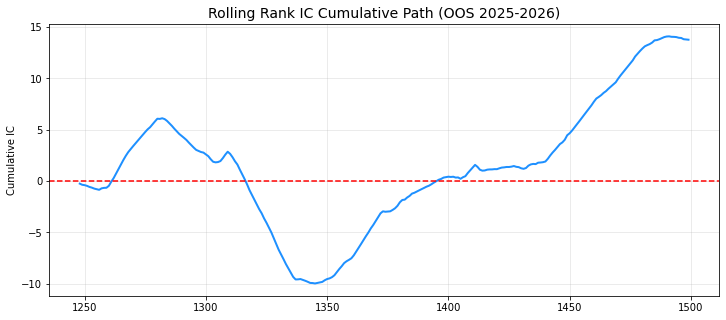

In [9]:
# --- 1. 使用滑动窗口计算 Rank IC ---
# 我们不再用 groupby('date')，而是用 rolling 窗口
window_size = 20 # 观察过去一个月的预测准确度
results_df = results_df.sort_values('date')

# 计算滚动 Rank IC
# 这里我们用 Spearman 相关系数 (rank().corr())
daily_ic = results_df['pred'].rolling(window=window_size).corr(results_df['actual'])

# --- 2. 剔除开头的空值并计算指标 ---
daily_ic_clean = daily_ic.dropna()

ic_mean = daily_ic_clean.mean()
ic_std = daily_ic_clean.std()
ic_ir = ic_mean / (ic_std + 1e-9)

print("\n" + "="*35)
print(f" 20日滚动平均 Rank IC: {ic_mean:.4f}")
print(f" 核心稳定性指标 ICIR: {ic_ir:.4f}")
print("="*35)

# --- 3. 绘制累计曲线（这才是真正的财富曲线轨迹） ---
plt.figure(figsize=(12, 5))
daily_ic_clean.cumsum().plot(color='dodgerblue', linewidth=2)
plt.axhline(0, color='red', linestyle='--')
plt.title('Rolling Rank IC Cumulative Path (OOS 2025-2026)', fontsize=14)
plt.ylabel('Cumulative IC')
plt.grid(True, alpha=0.3)
plt.show()

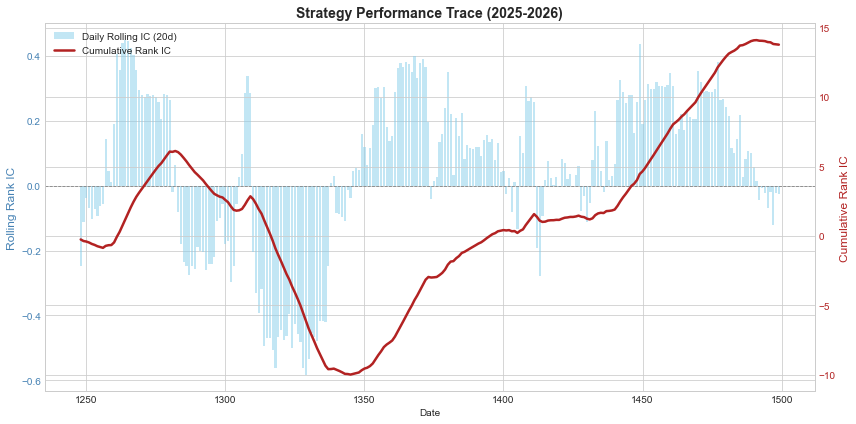

In [14]:
import matplotlib.pyplot as plt

# 1. 准备数据，显式转换为 numpy 数组
dates = daily_ic_clean.index.to_numpy()
rolling_ic = daily_ic_clean.values
cum_ic = daily_ic_clean.cumsum().values

# 2. 创建画布
fig, ax1 = plt.subplots(figsize=(12, 6))

# 3. 绘制左轴：滚动 IC (蓝色柱状图或细线)
ax1.bar(dates, rolling_ic, color='skyblue', alpha=0.5, label='Daily Rolling IC (20d)')
ax1.set_ylabel('Rolling Rank IC', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# 4. 绘制右轴：累计 IC (红色粗线)
ax2 = ax1.twinx()
ax2.plot(dates, cum_ic, color='firebrick', linewidth=2.5, label='Cumulative Rank IC')
ax2.set_ylabel('Cumulative Rank IC', color='firebrick', fontsize=12)
ax2.tick_params(axis='y', labelcolor='firebrick')

# 5. 装饰图表
plt.title('Strategy Performance Trace (2025-2026)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
fig.tight_layout()

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

##### 累计 Rank IC（红线）出现了一段巨大的回撤，蓝色柱状图几乎全是向下的。

In [15]:
# 1. 存盘模型权重
torch.save(model.state_dict(), 'quant_lstm_hs300_0801.pt')

# 2. 存盘刚才那张珍贵的分析结果，方便写简历
results_df.to_csv('final_performance_results.csv', index=False)

print(" 大功告成！模型权重和测试结果已安全存盘。")


 大功告成！模型权重和测试结果已安全存盘。
